In [98]:
import os
from typing import Iterable, Optional, Tuple, List, Dict, Union

import numpy as np
import pandas as pd
import rasterio
from rasterio.plot import plotting_extent
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from shapely.geometry import box

In [99]:
# CONFIG

BASE_DIR = r"E:\DEEPSENSE\figures"

# Representative TransectIDs
REPRESENTATIVE_TRANSECT_IDS: List[Union[int, str]] = [
    0, 8, 16, 23, 34, 43, 67, 86, 95, 104,
    120, 129, 149, 165, 173, 187, 198, 209, 223, 253,
    293, 302, 354, 366, 388, 400, 421, 479, 488, 510,
    537, 570, 586, 598, 662, 671, 714, 743, 754, 786,
    795, 811, 828, 844, 880, 899, 909, 924, 933, 941,
    956, 965,
]

# PATH
def build_paths(base_dir: str) -> Dict[str, str]:
    return {
        "tif": os.path.join(base_dir, "20210411_143234_composite.tif"),
        "veg_shp": os.path.join(base_dir, "coastline2_2020-10-12_2025-02-08_veglines.shp"),
        "wat_shp": os.path.join(base_dir, "coastline2_2020-10-12_2025-02-08_waterlines.shp"),
        "transects_shp": os.path.join(base_dir, "coastline2_Transects.shp"),
    }
PATHS = build_paths(BASE_DIR)

def assert_files_exist(paths: Iterable[str]) -> None:
    missing = [p for p in paths if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError(f"Missing files: {missing}")

In [100]:
# RGB BASE IMAGE

def read_rgb_alpha_from_multiband(
    tif_path: str,
    rgb_bands: Tuple[int, int, int] = (6, 4, 2),
    stretch: Tuple[float, float] = (2, 98),
):
    with rasterio.open(tif_path) as src:
        rgb = np.stack([src.read(b).astype("float32") for b in rgb_bands], axis=-1)

        mask = np.all(rgb == 0, axis=-1)

        valid = rgb[~mask]
        if valid.size > 0:
            lo = np.percentile(valid, stretch[0])
            hi = np.percentile(valid, stretch[1])
            rgb = np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)

        alpha = (~mask).astype("float32")
        rgba = np.dstack([rgb, alpha])

        extent = plotting_extent(src)
        crs = src.crs

    return rgba, extent, crs

In [101]:
# dates

def find_date_column(gdf: gpd.GeoDataFrame) -> str:
    for col in gdf.columns:
        name = col.lower()
        if "date" in name or "time" in name:
            return col
    raise ValueError("Could not find a column with 'date' or 'time' in its name.")


def add_datetime_column(
    gdf: gpd.GeoDataFrame,
    date_col: Optional[str] = None,
    new_col: str = "_dt",
) -> gpd.GeoDataFrame:
    if date_col is None:
        date_col = find_date_column(gdf)
    gdf[new_col] = pd.to_datetime(gdf[date_col], utc=True).dt.tz_convert(None)
    return gdf


def filter_by_dates(
    gdf: gpd.GeoDataFrame,
    dates: Optional[Union[str, List[str]]] = None,
    date_range: Optional[Tuple[str, str]] = None,
    date_col: str = "_dt",
) -> gpd.GeoDataFrame:
    df = gdf.copy()

    if dates is not None:
        if isinstance(dates, str):
            dates = [dates]
        wanted = pd.to_datetime(dates)
        df = df[df[date_col].isin(wanted)]

    if date_range is not None:
        start, end = pd.to_datetime(date_range)
        df = df[(df[date_col] >= start) & (df[date_col] <= end)]

    df = df.sort_values(date_col)
    return df


def describe_dates_for_plot(
    gdf: gpd.GeoDataFrame,
    date_col: str = "_dt",
) -> Tuple[str, str]:
    if date_col not in gdf.columns or gdf.empty:
        return "", ""

    dates = sorted(gdf[date_col].dt.date.unique())
    full_text = ", ".join(d.isoformat() for d in dates)

    if len(dates) <= 6:
        short_text = full_text
    else:
        head = ", ".join(d.isoformat() for d in dates[:3])
        tail = ", ".join(d.isoformat() for d in dates[-3:])
        short_text = f"{head}, ..., {tail}"

    return full_text, short_text

In [102]:
# COLORs
def create_veg_cmap() -> mcolors.Colormap:
    colors = [
        "#5B2A86",  # dark purple (low)
        "#BFA6D9",  # light purple
        "#FFFFFF",  # midpoint
        "#F4C19A",  # light orange
        "#E67E22",  # dark orange (high)
    ]
    return mcolors.LinearSegmentedColormap.from_list("NeonVeg", colors, N=256)


def create_water_high_cmap() -> mcolors.Colormap:
    colors = [
        "#5B2A86",  # dark purple (low)
        "#BFA6D9",  # light purple
        "#FFFFFF",  # midpoint
        "#F4C19A",  # light orange
        "#E67E22",  # dark orange (high)
    ]
    return mcolors.LinearSegmentedColormap.from_list("WaterHigh", colors, N=256)


MID_TIDE_COLOR = "#9D9281"
LOW_TIDE_COLOR = "#675040"
TRANSECT_BASE_COLOR = "#A0A0A0"
TRANSECT_REP_COLOR = "#FFFFFF"
TRANSECT_HIGHLIGHT_COLOR = "#FFD700"

In [103]:
# Plotting

def build_time_norm_for_one(
    gdf: gpd.GeoDataFrame,
    date_col: str = "_dt",
) -> mcolors.Normalize:
    if gdf.empty:
        raise ValueError("No features to build time normalization.")
    date_nums = mdates.date2num(gdf[date_col])
    vmin = date_nums.min()
    vmax = date_nums.max()
    if vmin == vmax:
        vmin -= 0.5
        vmax += 0.5
    return mcolors.Normalize(vmin=vmin, vmax=vmax)


def plot_lines_with_time_gradient(
    ax: plt.Axes,
    gdf: gpd.GeoDataFrame,
    norm: mcolors.Normalize,
    cmap: mcolors.Colormap,
    date_col: str = "_dt",
    linewidth: float = 0.5,
    alpha: float = 1.0,
) -> None:
    if gdf.empty:
        return

    date_nums = mdates.date2num(gdf[date_col])
    colors = cmap(norm(date_nums))

    bbox = box(-66.23715434458883, 45.16349241883057, -66.22198214394427, 45.17810437927076)
    cropped = gdf.clip(bbox)
    
    cropped.plot(
        ax=ax,
        # color=colors,
        cmap='viridis',
        linewidth=linewidth,
        alpha=alpha,
    )


def add_time_colorbar(
    fig: plt.Figure,
    ax: plt.Axes,
    norm: mcolors.Normalize,
    cmap: mcolors.Colormap,
    label: str,
) -> None:
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.03, pad=0.04)
    cbar.set_label(label, rotation=270, labelpad=20, fontsize=10)

    vmin, vmax = norm.vmin, norm.vmax
    ticks = np.linspace(vmin, vmax, 5)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([mdates.num2date(t).strftime("%Y-%m-%d") for t in ticks])


def add_dates_annotation(ax: plt.Axes, short_text: str) -> None:
    if not short_text:
        return
    ax.text(
        0.01,
        0.99,
        f"Dates: {short_text}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"),
    )

In [104]:
# transects overlay (all-grey, rep-white, selected example-yellow)

def load_transects_gdf(paths: Dict[str, str], target_crs) -> gpd.GeoDataFrame:
    assert_files_exist([paths["transects_shp"]])
    gdf = gpd.read_file(paths["transects_shp"])
    if gdf.crs is None:
        gdf = gdf.set_crs(target_crs)
    else:
        gdf = gdf.to_crs(target_crs)
    return gdf

def plot_transects_with_highlights(
    ax: plt.Axes,
    transects: gpd.GeoDataFrame,
    highlight_id: Optional[Union[int, str]] = None,
    base_linewidth: float = 0.4,
    rep_linewidth: float = 1.0,
    highlight_linewidth: float = 1.6,
) -> None:
    # Plot base transects, representative transects, and a highlighted transect
    if transects is None or transects.empty:
        return

    if "TransectID" not in transects.columns:
        raise ValueError("Transects shapefile must contain a 'TransectID' column.")

    transects["_id_str"] = transects["TransectID"].astype(str)

    rep_ids_str = {str(x) for x in REPRESENTATIVE_TRANSECT_IDS}
    highlight_id_str = str(highlight_id) if highlight_id is not None else None

    # 1) Base layer: all transects, grey, alpha 0.5
    transects.plot(
        ax=ax,
        color=TRANSECT_BASE_COLOR,
        linewidth=base_linewidth,
        alpha=0.5,
    )

    # 2) Representative transects, white, alpha 0.8
    reps = transects[transects["_id_str"].isin(rep_ids_str)]
    if not reps.empty:
        reps.plot(
            ax=ax,
            color=TRANSECT_REP_COLOR,
            linewidth=rep_linewidth,
            alpha=0.8,
        )

    # 3) Highlight one transect, gold, alpha 1.0
    hi = gpd.GeoDataFrame(columns=transects.columns, geometry="geometry")
    if highlight_id_str is not None:
        hi = transects[transects["_id_str"] == highlight_id_str]
        if not hi.empty:
            hi.plot(
                ax=ax,
                color=TRANSECT_HIGHLIGHT_COLOR,
                linewidth=highlight_linewidth,
                alpha=1.0,
            )

    # Legend for transects: bottom-right of the figure
    legend_handles = [
        Line2D([0], [0], color=TRANSECT_BASE_COLOR, lw=base_linewidth, label="All transects"),
    ]
    if not reps.empty:
        legend_handles.append(
            Line2D([0], [0], color=TRANSECT_REP_COLOR, lw=rep_linewidth, label="Representative transects")
        )
    if not hi.empty:
        legend_handles.append(
            Line2D([0], [0], color=TRANSECT_HIGHLIGHT_COLOR, lw=highlight_linewidth,
                   label=f"Transect {highlight_id_str}")
        )

    if legend_handles:
        legend_tr = ax.legend(
            handles=legend_handles,
            loc="lower right",
            bbox_to_anchor=(1.3, 0),
            borderaxespad=0.2,
            frameon=True,
        )

        # --- Style legend background ---
        frame = legend_tr.get_frame()
        frame.set_facecolor("#F0F0F0C6")   # light grey background
        frame.set_edgecolor("#4D4D4D")   # dark grey border
        frame.set_linewidth(0.8)
        frame.set_alpha(1.0)

        ax.add_artist(legend_tr)

In [105]:
# VEGLINE PLOTTING

def overlay_veg_lines(
    paths: Dict[str, str],
    dates: Optional[Union[str, List[str]]] = None,
    date_range: Optional[Tuple[str, str]] = None,
    linewidth: float = 0.7,
    show_transects: bool = False,
    highlight_transect: Optional[Union[int, str]] = 30,
) -> None:
    assert_files_exist([paths["tif"], paths["veg_shp"]])

    rgba, extent, crs = read_rgb_alpha_from_multiband(paths["tif"])

    veg = gpd.read_file(paths["veg_shp"]).to_crs(crs)
    veg = add_datetime_column(veg)
    veg = filter_by_dates(veg, dates=dates, date_range=date_range)

    if veg.empty:
        print("No VEG lines found for the selected dates.")
        return

    use_filter = (dates is not None) or (date_range is not None)
    full_dates, short_dates = ("", "")
    if use_filter:
        full_dates, short_dates = describe_dates_for_plot(veg)
        print(f"Veg dates plotted: {full_dates}")

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(rgba, extent=extent, origin="upper")

    norm = build_time_norm_for_one(veg)
    veg_cmap = create_veg_cmap()

    plot_lines_with_time_gradient(
        ax=ax,
        gdf=veg,
        norm=norm,
        cmap=veg_cmap,
        linewidth=linewidth,
        alpha=0.9,
    )

    add_time_colorbar(
        fig=fig,
        ax=ax,
        norm=norm,
        cmap=veg_cmap,
        label="Vegline time (old → new)",
    )

    if show_transects:
        transects = load_transects_gdf(paths, crs)
        plot_transects_with_highlights(
            ax=ax,
            transects=transects,
            highlight_id=highlight_transect,
        )

    if use_filter:
        add_dates_annotation(ax, short_dates)

    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_title("Veglines over RGB composite", fontsize=14)
    ax.axis("off")

    plt.show()

In [106]:
# WATERLINE PLOTTING

def overlay_water_lines(
    paths: Dict[str, str],
    dates: Optional[Union[str, List[str]]] = None,
    date_range: Optional[Tuple[str, str]] = None,
    linewidth_high: float = 0.6,
    linewidth_midlow: float = 0.5,
    alpha_midlow: float = 0.4,
    show_transects: bool = False,
    highlight_transect: Optional[Union[int, str]] = 30,
) -> None:
    """
    High tide: blue, time gradient + colorbar
    Mid tide: light brown
    Low tide: dark brown
    Transects: grey base, white reps, gold highlight on top
    """
    assert_files_exist([paths["tif"], paths["wat_shp"]])

    rgba, extent, crs = read_rgb_alpha_from_multiband(paths["tif"])

    water = gpd.read_file(paths["wat_shp"]).to_crs(crs)
    water = add_datetime_column(water)

    if "tidetype" not in water.columns:
        raise ValueError("Waterlines shapefile must contain a 'tidetype' column.")

    water["tidetype_clean"] = water["tidetype"].astype(str).str.lower().str.strip()

    water = filter_by_dates(water, dates=dates, date_range=date_range)

    if water.empty:
        print("No WATER lines found for the selected dates.")
        return

    use_filter = (dates is not None) or (date_range is not None)
    full_dates, short_dates = ("", "")
    if use_filter:
        full_dates, short_dates = describe_dates_for_plot(water)
        print(f"Water dates plotted: {full_dates}")

    high = water[water["tidetype_clean"] == "high"]
    mid = water[water["tidetype_clean"].isin(["middle", "mid"])]
    low = water[water["tidetype_clean"] == "low"]

    if high.empty and mid.empty and low.empty:
        print("No WATER lines with valid 'tidetype' values (high/mid/low).")
        return

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(rgba, extent=extent, origin="upper")

    if not mid.empty:
        mid.plot(
            ax=ax,
            color=MID_TIDE_COLOR,
            linewidth=linewidth_midlow,
            alpha=alpha_midlow,
        )

    if not low.empty:
        low.plot(
            ax=ax,
            color=LOW_TIDE_COLOR,
            linewidth=linewidth_midlow,
            alpha=alpha_midlow,
        )

    high_cmap = create_water_high_cmap()
    norm_high = None

    if not high.empty:
        norm_high = build_time_norm_for_one(high)
        plot_lines_with_time_gradient(
            ax=ax,
            gdf=high,
            norm=norm_high,
            cmap=high_cmap,
            linewidth=linewidth_high,
            alpha=0.95,
        )

        add_time_colorbar(
            fig=fig,
            ax=ax,
            norm=norm_high,
            cmap=high_cmap,
            label="High tide time (old → new)",
        )

    # overlay transects ON TOP of waterlines
    if show_transects:
        transects = load_transects_gdf(paths, crs)
        plot_transects_with_highlights(
            ax=ax,
            transects=transects,
            highlight_id=highlight_transect,
        )

    # Tide legend
    tide_handles = []

    if not high.empty and norm_high is not None:
        mid_val = 0.5 * (norm_high.vmin + norm_high.vmax)
        high_color_for_legend = high_cmap(norm_high(mid_val))
        tide_handles.append(
            Line2D([0], [0], color=high_color_for_legend, lw=linewidth_high, label="High tide")
        )

    if not mid.empty:
        tide_handles.append(
            Line2D([0], [0], color=MID_TIDE_COLOR, lw=linewidth_midlow, label="Mid tide")
        )

    if not low.empty:
        tide_handles.append(
            Line2D([0], [0], color=LOW_TIDE_COLOR, lw=linewidth_midlow, label="Low tide")
        )

    if tide_handles:
        ax.legend(handles=tide_handles, loc="lower left")

    if use_filter:
        add_dates_annotation(ax, short_dates)

    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_title("Waterlines over RGB composite", fontsize=14)
    ax.axis("off")

    plt.show()

calls

Veg dates plotted: 2021-04-14


C:\Users\CPK\AppData\Local\Temp\ipykernel_33096\3887054743.py:36: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  cropped.plot(


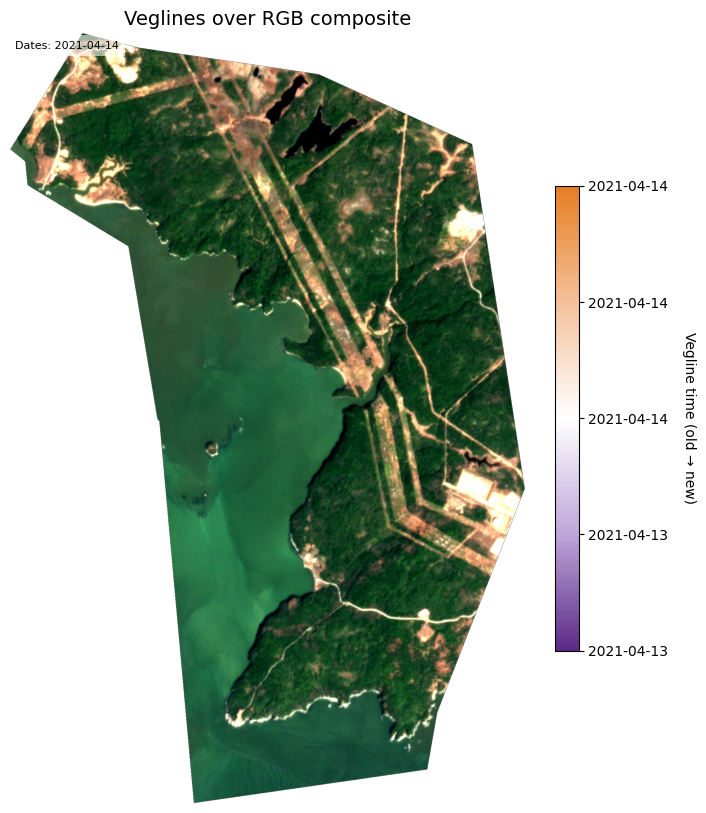

In [107]:
# one vegline
overlay_veg_lines(
    paths=PATHS,
    dates="2021-04-14",
    show_transects=False,
)

Water dates plotted: 2021-04-11, 2021-04-14


C:\Users\CPK\AppData\Local\Temp\ipykernel_33096\3887054743.py:36: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  cropped.plot(


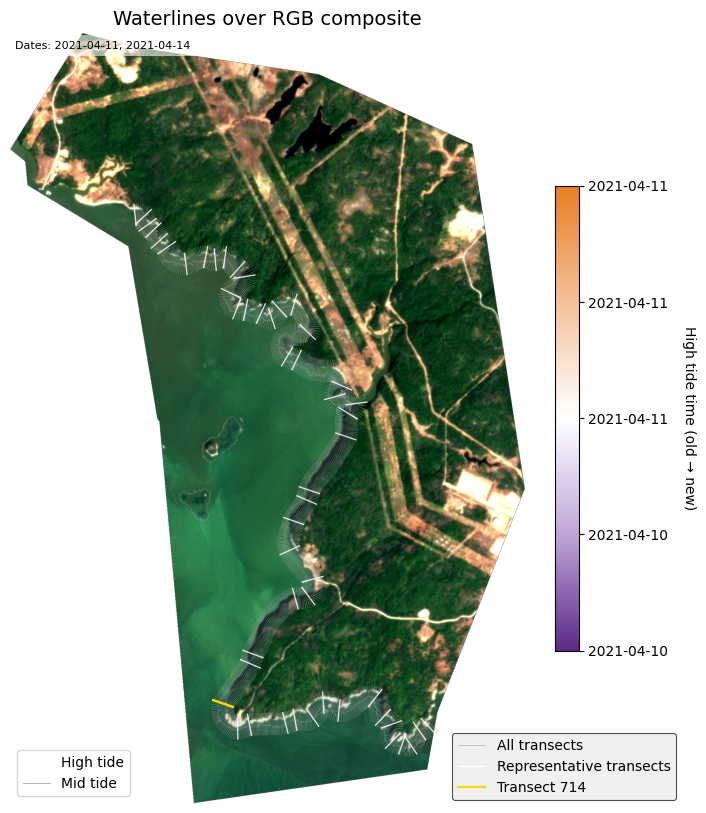

In [108]:
# list [dates] water
overlay_water_lines(
    paths=PATHS,
    dates=["2021-04-11", "2021-04-12", "2021-04-14"],
    show_transects=True,
    highlight_transect=714,
)


C:\Users\CPK\AppData\Local\Temp\ipykernel_33096\3887054743.py:36: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  cropped.plot(


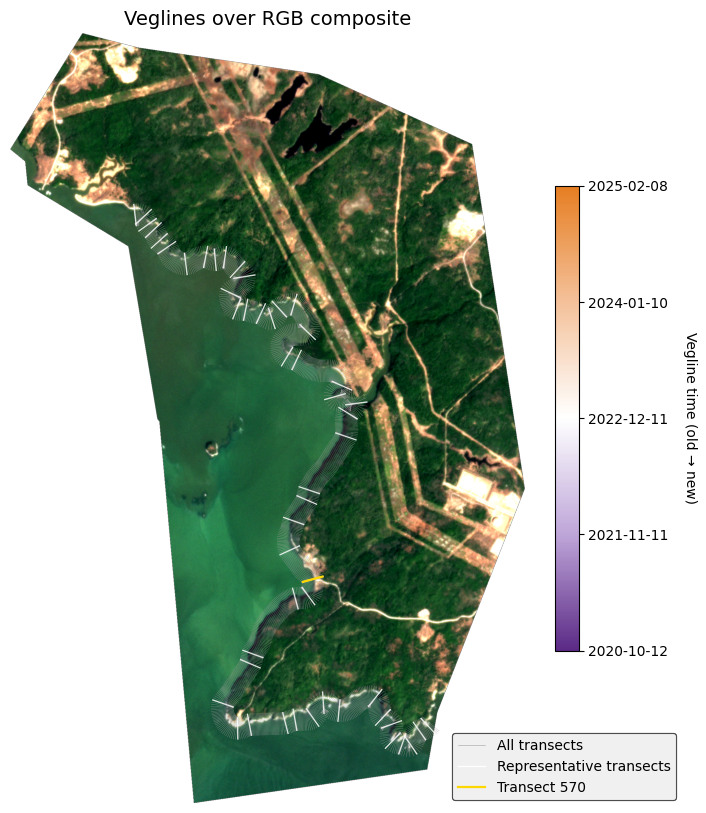

C:\Users\CPK\AppData\Local\Temp\ipykernel_33096\3887054743.py:36: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  cropped.plot(


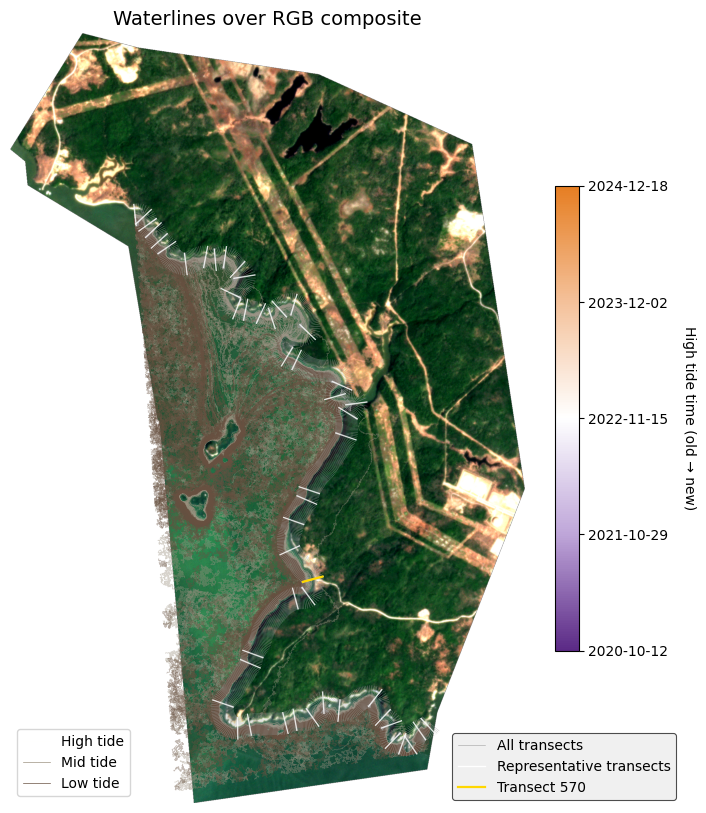

In [109]:
# all dates veg
overlay_veg_lines(
    paths=PATHS,
    dates=None,
    date_range=None,
    show_transects=True,
    highlight_transect=570,
)

# all dates water
overlay_water_lines(
    paths=PATHS,
    dates=None,
    date_range=None,
    show_transects=True,
    highlight_transect=570,
)